In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from typing import List, Tuple
import numpy as np

%matplotlib widget

In [2]:
FILE_PATH = "..\\..\\data\\radar\\radar_points_world.csv"

FPS = 24
PERSIST_STATIC_POINTS = True
REPEAT_ANIMATION = False
VELOCITY_THRESHOLD = 0.1

COL_X = "x_sensor"
COL_Y = "y_sensor"
COL_Z = "z_sensor"
COL_VELOCITY = "radial_velocity"
COL_FRAME = "frame"
COL_TIMESTAMP = "timestamp"

COLOR_MAP = "coolwarm"
MARKER_SIZE = 15
ANIMATION_INTERVAL = 1000 // FPS
ELEVATION = 20
AZIMUTH = -35
FIG_WIDTH = 10
FIG_HEIGHT = 8

SENSOR_X = 0
SENSOR_Y = 0
SENSOR_Z = 0
SENSOR_COLOR = "green"
SENSOR_STYLE = "X"
SENSOR_SIZE = 100
BG_COLOR = "#121212"
TEXT_COLOR = "white"

LABEL_X = "X (Sensor) [m]"
LABEL_Y = "Y (Sensor) [m]"
LABEL_Z = "Z (Sensor) [m]"
LABEL_VELOCITY = "Velocity [m/s]"
PLOT_TITLE = "Radar 3D - Static Map vs Moving Objects"
TIME_TEXT_TEMPLATE = "Time: {:.2f}s / {:.2f}s\nThreshold: {} m/s"
SENSOR_LABEL = "Sensor"

In [3]:
class RadarDataLoader:
    def __init__(self, filePath: str):
        self.filePath = filePath
        self.dataFrame = pd.DataFrame()
        self.uniqueFrames: List[int] = []
        self.startTimestamp: float = 0.0
        self.totalDuration: float = 0.0

    def load(self) -> bool:
        try:
            self.dataFrame = pd.read_csv(self.filePath)
            self.uniqueFrames = sorted(self.dataFrame[COL_FRAME].unique().tolist())
            self.startTimestamp = float(self.dataFrame[COL_TIMESTAMP].min())
            self.totalDuration = float(self.dataFrame[COL_TIMESTAMP].max()) - self.startTimestamp
            return not self.dataFrame.empty
        except Exception:
            return False

    def getFrameData(self, frameId: int) -> Tuple[pd.Series, pd.Series, pd.Series, pd.Series, float]:
        frameMask = self.dataFrame[COL_FRAME] == frameId
        frameData = self.dataFrame[frameMask]
        currentTimestamp = float(frameData[COL_TIMESTAMP].iloc[0])
        relativeTime = currentTimestamp - self.startTimestamp
        return frameData[COL_X], frameData[COL_Y], frameData[COL_Z], frameData[COL_VELOCITY], relativeTime

    def getAxisLimits(self) -> List[Tuple[float, float]]:
        return [
            (float(self.dataFrame[COL_X].min()), float(self.dataFrame[COL_X].max())),
            (float(self.dataFrame[COL_Y].min()), float(self.dataFrame[COL_Y].max())),
            (float(self.dataFrame[COL_Z].min()), float(self.dataFrame[COL_Z].max()))
        ]

    def getVelocityLimits(self) -> Tuple[float, float]:
        return float(self.dataFrame[COL_VELOCITY].min()), float(self.dataFrame[COL_VELOCITY].max())

In [4]:
class RadarVisualizer:
    def __init__(self, dataLoader: RadarDataLoader):
        self.dataLoader = dataLoader
        self.fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT))
        self.ax = self.fig.add_subplot(111, projection="3d")
        self.scatter = self.ax.scatter([], [], [], c=[], cmap=COLOR_MAP, s=MARKER_SIZE)
        self.timeText = self.ax.text2D(0.05, 0.95, "", transform=self.ax.transAxes, color=TEXT_COLOR, fontsize=10)
        
        self.staticX: List[float] = []
        self.staticY: List[float] = []
        self.staticZ: List[float] = []
        self.staticV: List[float] = []
        self.animation: FuncAnimation | None = None

    def initializeAxes(self) -> None:
        limits = self.dataLoader.getAxisLimits()
        vMin, vMax = self.dataLoader.getVelocityLimits()
        
        self.ax.set_xlim3d(limits[0])
        self.ax.set_ylim3d(limits[1])
        self.ax.set_zlim3d(limits[2])
        self.ax.set_xlabel(LABEL_X, color=TEXT_COLOR)
        self.ax.set_ylabel(LABEL_Y, color=TEXT_COLOR)
        self.ax.set_zlabel(LABEL_Z, color=TEXT_COLOR)
        self.ax.set_title(PLOT_TITLE, color=TEXT_COLOR)
        self.ax.view_init(elev=ELEVATION, azim=AZIMUTH)
        
        self.ax.set_facecolor(BG_COLOR)
        self.fig.patch.set_facecolor(BG_COLOR)
        for axis in [self.ax.xaxis, self.ax.yaxis, self.ax.zaxis]:
            self.ax.tick_params(axis=axis.axis_name, colors=TEXT_COLOR)

        self.scatter.set_clim(vMin, vMax)
        colorBar = self.fig.colorbar(self.scatter, ax=self.ax, pad=0.1)
        colorBar.set_label(LABEL_VELOCITY, color=TEXT_COLOR)
        plt.setp(plt.getp(colorBar.ax.axes, "yticklabels"), color=TEXT_COLOR)
        
        self.ax.scatter([SENSOR_X], [SENSOR_Y], [SENSOR_Z], color=SENSOR_COLOR, marker=SENSOR_STYLE, s=SENSOR_SIZE, label=SENSOR_LABEL)
        self.ax.legend()

    def update(self, frameId: int):
        x, y, z, velocity, relTime = self.dataLoader.getFrameData(frameId)
        
        if PERSIST_STATIC_POINTS:
            isStatic = velocity.abs() < VELOCITY_THRESHOLD
            self.staticX.extend(x[isStatic].tolist())
            self.staticY.extend(y[isStatic].tolist())
            self.staticZ.extend(z[isStatic].tolist())
            self.staticV.extend(velocity[isStatic].tolist())
            
            isMoving = velocity.abs() >= VELOCITY_THRESHOLD
            outX = self.staticX + x[isMoving].tolist()
            outY = self.staticY + y[isMoving].tolist()
            outZ = self.staticZ + z[isMoving].tolist()
            outV = self.staticV + velocity[isMoving].tolist()
        else:
            outX, outY, outZ, outV = x.tolist(), y.tolist(), z.tolist(), velocity.tolist()

        self.scatter._offsets3d = (outX, outY, outZ)
        self.scatter.set_array(np.array(outV))
        
        self.timeText.set_text(TIME_TEXT_TEMPLATE.format(relTime, self.dataLoader.totalDuration, VELOCITY_THRESHOLD))
        return self.scatter, self.timeText

    def start(self) -> FuncAnimation:
        self.initializeAxes()
        self.animation = FuncAnimation(
            self.fig,
            self.update,
            frames=self.dataLoader.uniqueFrames,
            interval=ANIMATION_INTERVAL,
            blit=False,
            repeat=REPEAT_ANIMATION
        )
        return self.animation

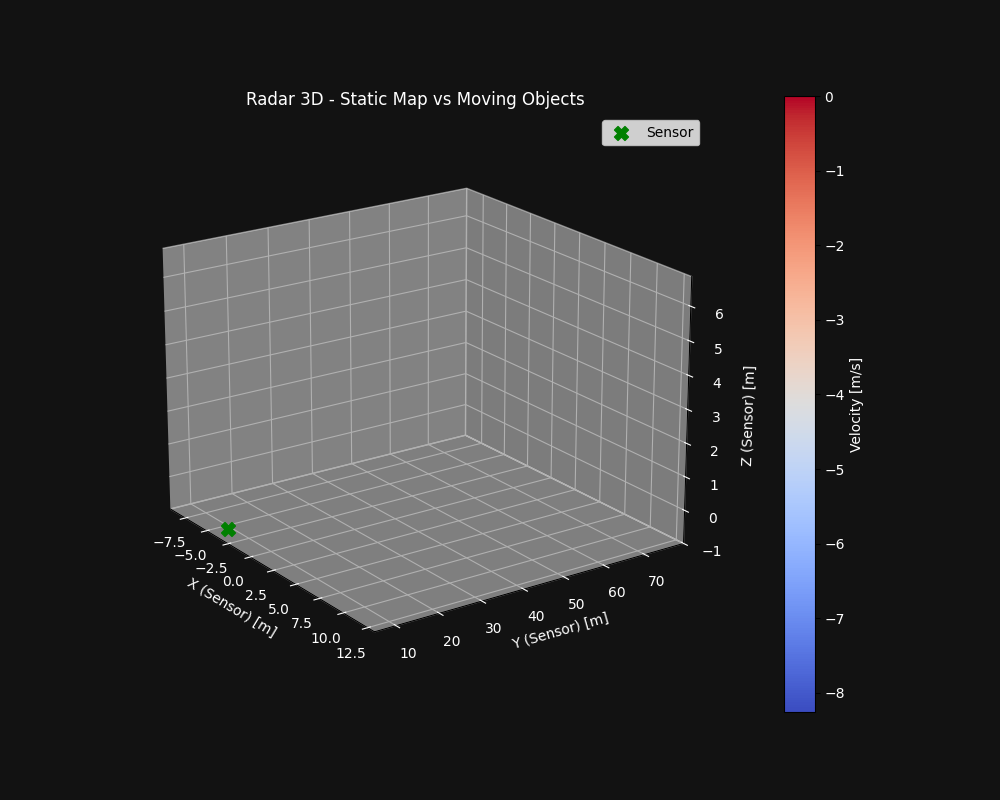

In [5]:
if __name__ == "__main__":
    loader = RadarDataLoader(FILE_PATH)
    if loader.load():
        visualizer = RadarVisualizer(loader)
        radarAnim = visualizer.start()
        plt.show()